Searching for Optuna study databases in ../checkpoints/metalearning2/ProtoNet

Processing database: ../checkpoints/metalearning2/ProtoNet\ChenB_2020\TSChenB_2020_TK10_unbalanced_sun et al_ProtoNet_Tspecies_\optuna_study.db
Found studies: ['hyper-param_optimization_for_zw8uirkj']
Loading study 'hyper-param_optimization_for_zw8uirkj'...
Study 'hyper-param_optimization_for_zw8uirkj' has 35 completed trials
Using FanovaImportanceEvaluator
Successfully calculated importance for 7 parameters
✅ Successfully extracted importance data from TSChenB_2020

Processing database: ../checkpoints/metalearning2/ProtoNet\ChuY_2021\TSChuY_2021_TK10_unbalanced_sun et al_ProtoNet_Tspecies_\optuna_study.db
Found studies: ['hyper-param_optimization_for_pk2ncajk']
Loading study 'hyper-param_optimization_for_pk2ncajk'...
Study 'hyper-param_optimization_for_pk2ncajk' has 35 completed trials
Using FanovaImportanceEvaluator
Successfully calculated importance for 7 parameters
✅ Successfully extracted importance dat

C:\Users\shaya\AppData\Local\Temp\ipykernel_31156\2655303139.py:502: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels=boxplot_labels, vert=True, patch_artist=True)
C:\Users\shaya\AppData\Local\Temp\ipykernel_31156\2655303139.py:502: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels=boxplot_labels, vert=True, patch_artist=True)
C:\Users\shaya\AppData\Local\Temp\ipykernel_31156\2655303139.py:502: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels=boxplot_labels, vert=True, patch_artist=True)
C:\Users\shaya\AppData\Local\Temp\ipykernel_31

Boxplot saved to hyperparameter_boxplots.png
Generating parameter scatter comparison plots...
Scatter comparison plot saved to hyperparameter_scatter_comparison.png

Analysis complete. Output files:
  - hyperparameter_importance.png
  - importance_heatmap.png
  - hyperparameter_boxplots.png
  - hyperparameter_scatter_comparison.png


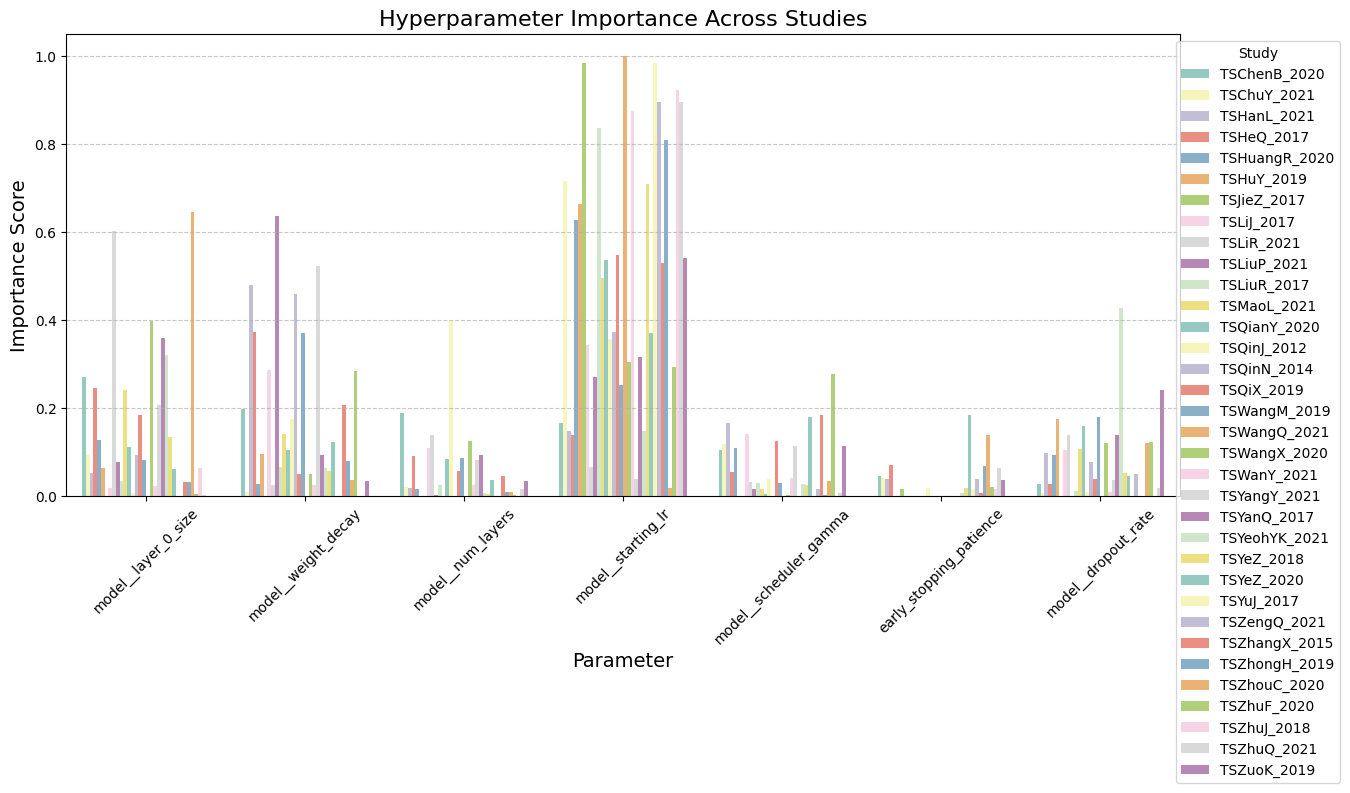

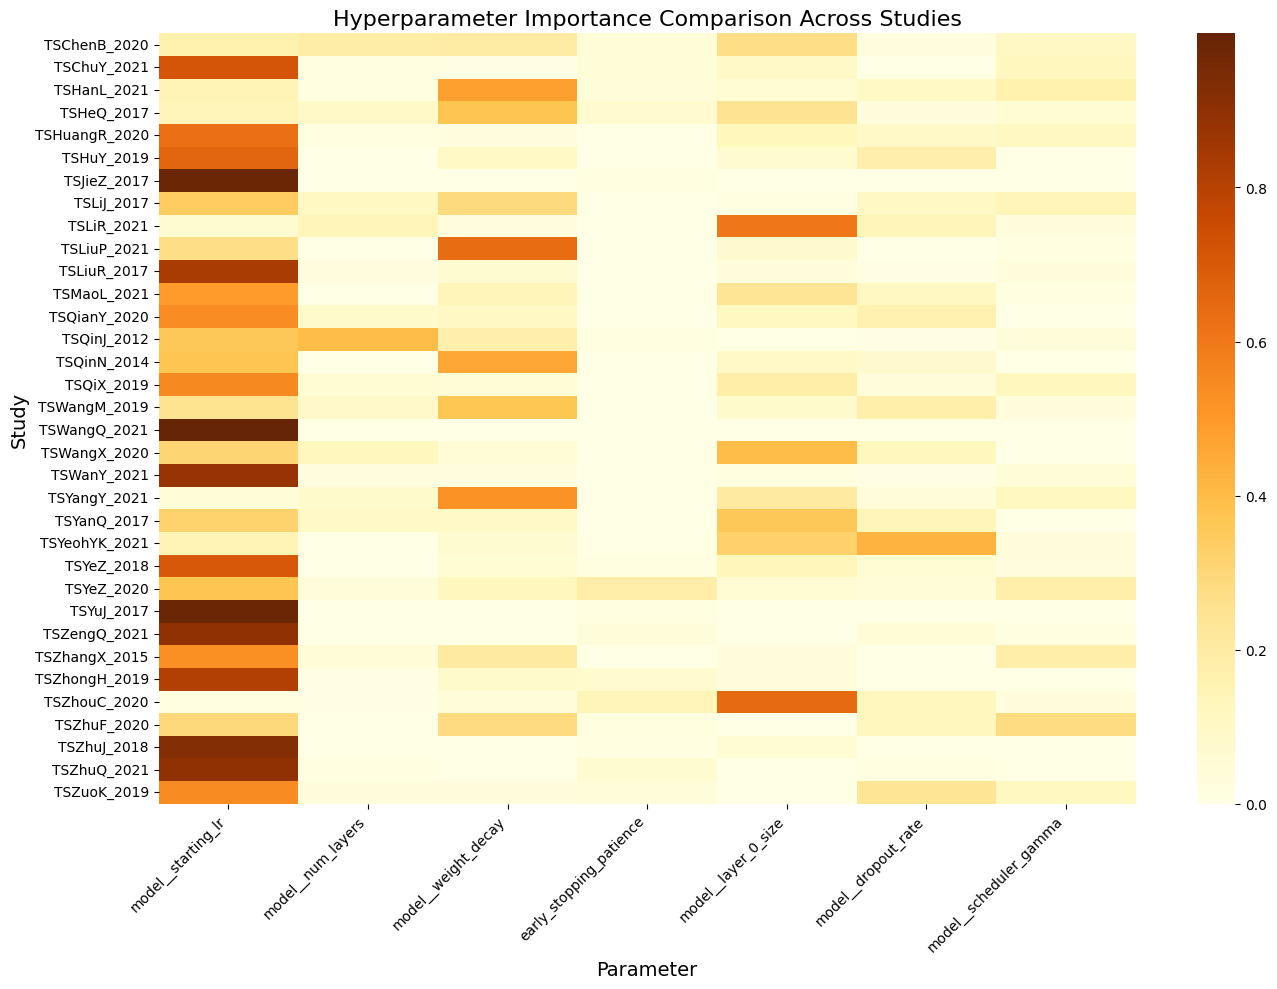

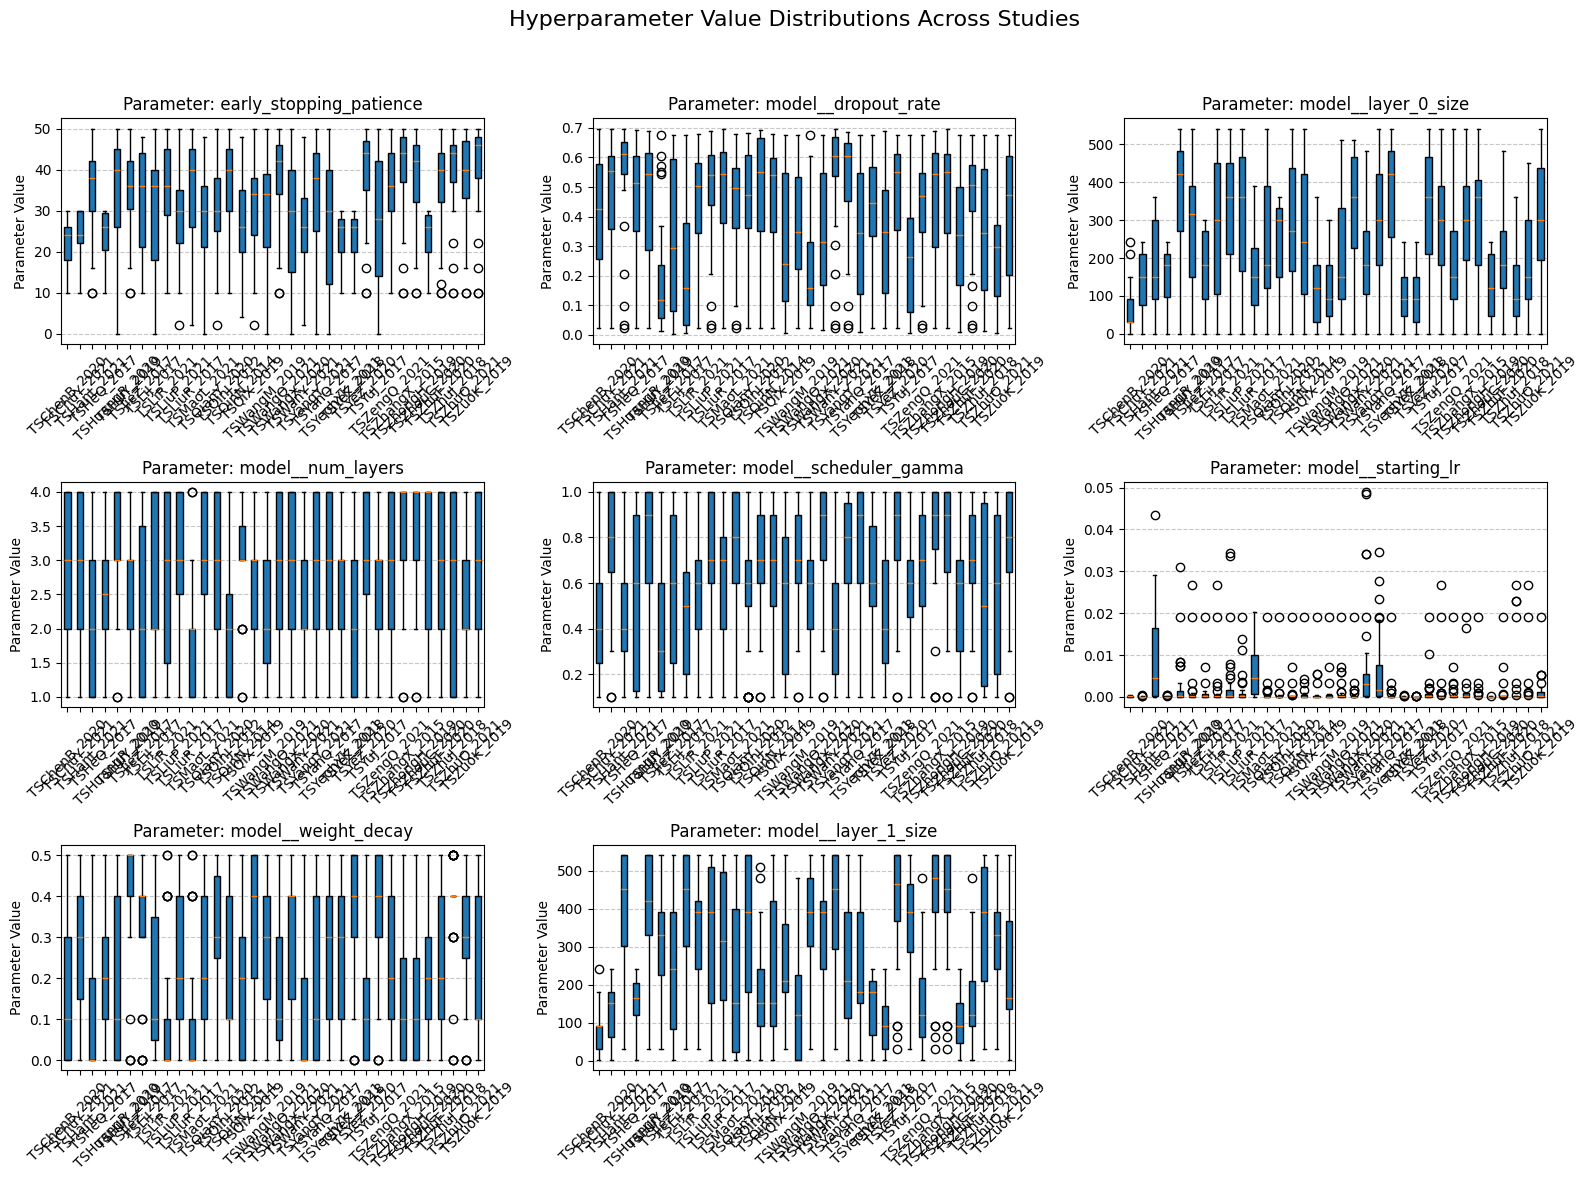

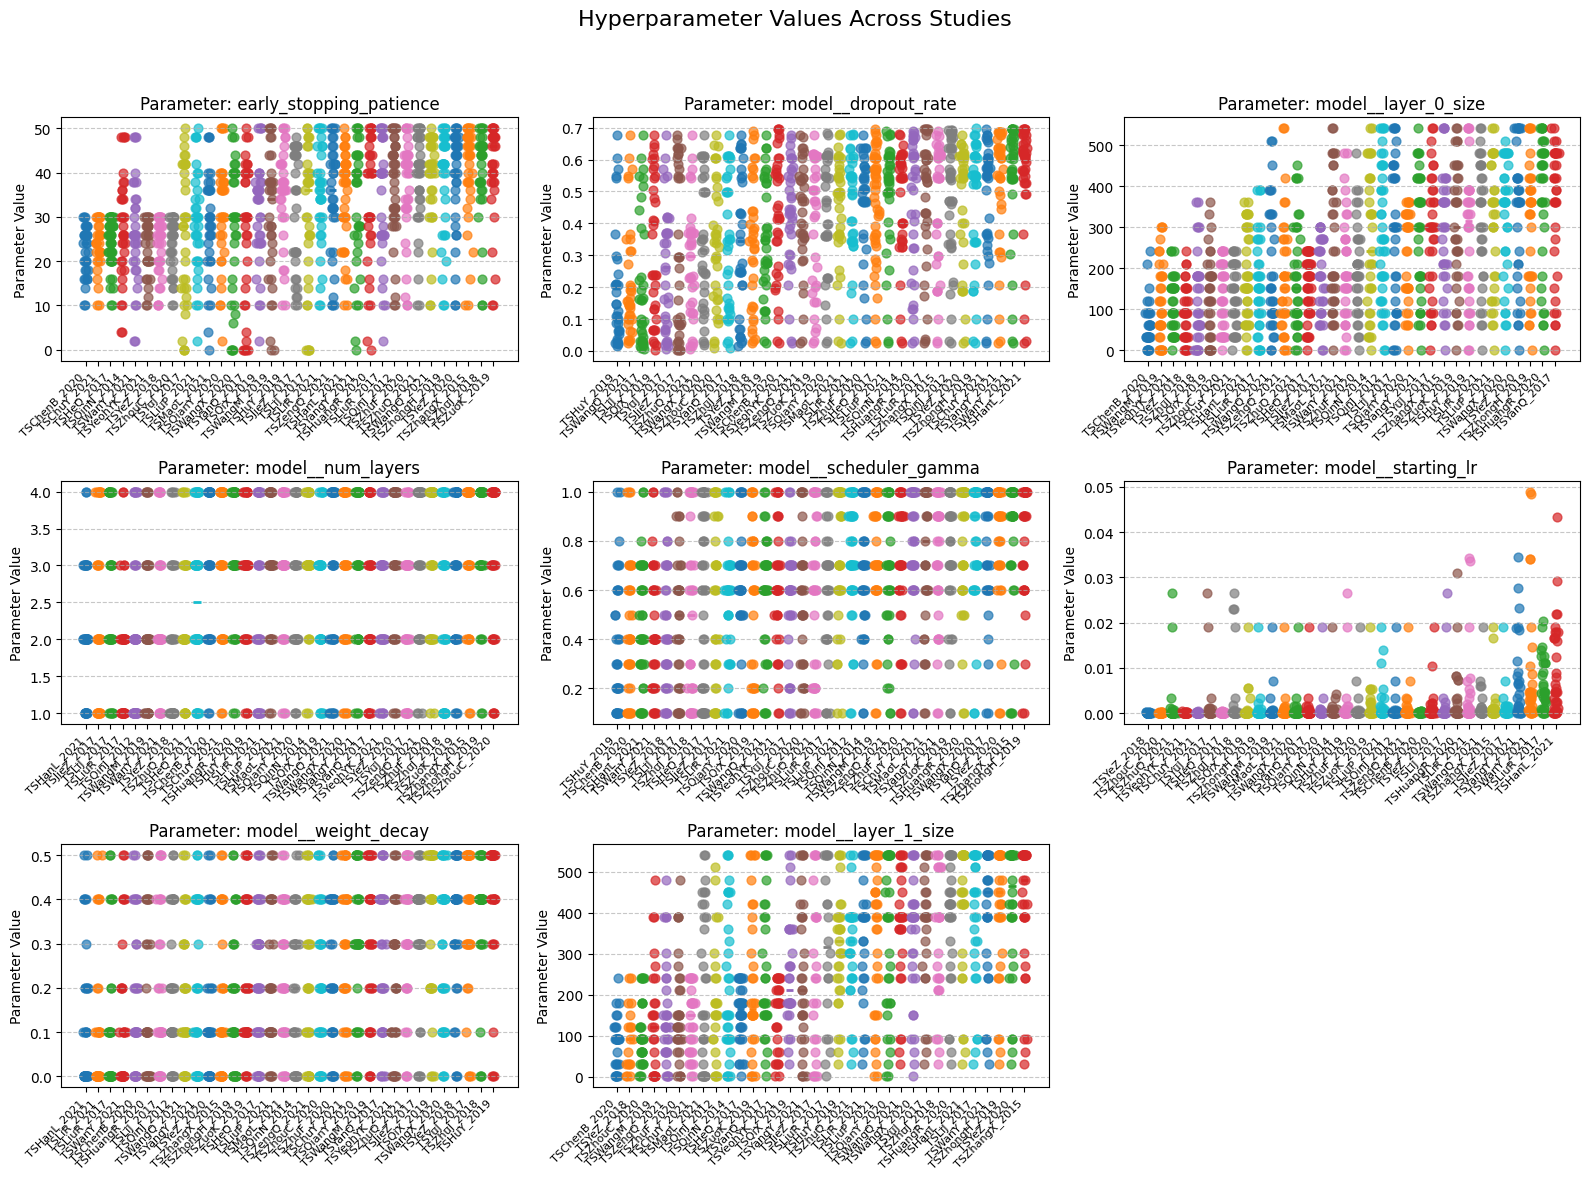

In [27]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.figure import Figure
from typing import Dict, List, Tuple, Optional
import numpy as np
import json
import traceback
import warnings
import optuna
from optuna.importance import get_param_importances, FanovaImportanceEvaluator
from optuna.study import Study


def extract_importance_from_db(db_path: str) -> Optional[Dict[str, float]]:
    """
    Extract hyperparameter importance from an Optuna study database using Optuna's
    built-in importance calculation.
    
    Args:
        db_path: Path to the optuna_study.db file
        
    Returns:
        Dictionary mapping parameter names to their importance values,
        or None if importance data couldn't be extracted
    """
    try:
        # Get the storage URL from the database path
        storage_url = f"sqlite:///{db_path}"
        
        # Get study names from the database
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.execute("SELECT study_name FROM studies")
        study_names = [row[0] for row in cursor.fetchall()]
        conn.close()
        
        if not study_names:
            print(f"No studies found in {db_path}")
            return None
            
        print(f"Found studies: {study_names}")
        
        # Try to load each study and calculate importance
        for study_name in study_names:
            try:
                # Load the study from the database
                print(f"Loading study '{study_name}'...")
                study = optuna.load_study(study_name=study_name, storage=storage_url)
                
                # Check if the study has completed trials
                completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
                if not completed_trials:
                    print(f"Study '{study_name}' has no completed trials")
                    continue
                    
                print(f"Study '{study_name}' has {len(completed_trials)} completed trials")
                
                # Calculate parameter importance using optuna's built-in function
                try:
                    # FanovaImportanceEvaluator can be slow for large number of trials
                    if len(completed_trials) > 1000:
                        print("Using MeanDecreaseImpurityImportanceEvaluator for large number of trials")
                        evaluator = optuna.importance.MeanDecreaseImpurityImportanceEvaluator()
                    else:
                        print("Using FanovaImportanceEvaluator")
                        evaluator = FanovaImportanceEvaluator()
                        
                    importance_data = get_param_importances(study, evaluator=evaluator)
                    
                    if importance_data:
                        print(f"Successfully calculated importance for {len(importance_data)} parameters")
                        return importance_data
                except Exception as e:
                    print(f"Error calculating importance for study '{study_name}': {e}")
                    traceback.print_exc()
            
            except Exception as e:
                print(f"Error loading study '{study_name}': {e}")
                traceback.print_exc()
        
        print("Could not calculate importance for any study in the database")
        return None
        
    except Exception as e:
        print(f"Error accessing database {db_path}: {e}")
        traceback.print_exc()
        return None


def collect_all_importance_data(root_dir: str) -> List[Tuple[str, Dict[str, float]]]:
    """
    Collect hyperparameter importance data from all optuna_study.db files 
    in subdirectories of the given root directory.
    
    Args:
        root_dir: Root directory to search in
        
    Returns:
        List of tuples containing (directory_name, importance_data)
    """
    all_data = []
    found_dbs = 0
    processed_dbs = 0
    
    # Walk through all directories
    for dirpath, dirnames, filenames in os.walk(root_dir):
        # Skip the root directory itself
        if dirpath == root_dir:
            continue
            
        # Check for database files with common optuna database names
        db_files = [f for f in filenames if f.lower() in ["optuna_study.db", "optuna.db", "study.db"]]
        
        for db_file in db_files:
            found_dbs += 1
            db_path = os.path.join(dirpath, db_file)
            print(f"\nProcessing database: {db_path}")
            
            # Extract the importance data
            try:
                importance_data = extract_importance_from_db(db_path)
                
                if importance_data:
                    processed_dbs += 1
                    # Use the directory name as an identifier
                    dir_name = os.path.basename(dirpath).split("_")[0:2]
                    dir_name = "_".join(dir_name)
                    all_data.append((dir_name, importance_data))
                    print(f"✅ Successfully extracted importance data from {dir_name}")
                else:
                    print(f"❌ No usable importance data found in {os.path.basename(dirpath)}")
            except Exception as e:
                print(f"❌ Error processing {db_path}: {e}")
                traceback.print_exc()
            
    print(f"\nSummary: Found {found_dbs} databases, successfully processed {processed_dbs}")
    if found_dbs > 0 and processed_dbs == 0:
        print("\nTroubleshooting suggestions:")
        print("  - Check if you have the optuna package installed: pip install optuna")
        print("  - Verify that your Optuna version is compatible with your database schema")
        print("  - Ensure studies contain completed trials")
        print("  - Try installing optuna-fast-fanova if you have many trials: pip install optuna-fast-fanova")
            
    return all_data


def plot_importance_data(all_importance_data: List[Tuple[str, Dict[str, float]]], 
                         output_path: str = "hyperparameter_importance.png",
                         top_n: int = 10,
                         figsize: Tuple[int, int] = (12, 8)) -> Figure:
    """
    Plot hyperparameter importance data from multiple studies.
    
    Args:
        all_importance_data: List of tuples containing (directory_name, importance_data)
        output_path: Path to save the output figure
        top_n: Number of top parameters to display
        figsize: Figure size as (width, height)
        
    Returns:
        Matplotlib Figure object
    """
    if not all_importance_data:
        print("No importance data to plot.")
        return None
        
    # Prepare the data for plotting
    plot_data = []
    
    for dir_name, importance in all_importance_data:
        # Sort parameters by importance
        sorted_params = sorted(importance.items(), key=lambda x: x[1], reverse=True)
        
        # Take the top N parameters
        for i, (param, value) in enumerate(sorted_params[:top_n]):
            plot_data.append({
                'Directory': dir_name,
                'Parameter': param,
                'Importance': value,
                'Rank': i + 1
            })
    
    # Convert to DataFrame for easier plotting
    df = pd.DataFrame(plot_data)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create a grouped bar chart
    sns.barplot(
        data=df,
        x='Parameter',
        y='Importance',
        hue='Directory',
        ax=ax,
        palette='Set3',
    )
    
    # Enhance the plot
    ax.set_title('Hyperparameter Importance Across Studies', fontsize=16)
    ax.set_xlabel('Parameter', fontsize=14)
    ax.set_ylabel('Importance Score', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    
    # Add a grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Adjust layout for the legend
    plt.tight_layout()
    plt.legend(title='Study', loc='upper right', bbox_to_anchor=(1.15, 1))
    
    # Save the figure
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_path}")
    
    return fig


def create_heatmap_comparison(all_importance_data: List[Tuple[str, Dict[str, float]]],
                             output_path: str = "importance_heatmap.png",
                             figsize: Tuple[int, int] = (14, 10)) -> Figure:
    """
    Create a heatmap comparing parameter importance across different studies.
    
    Args:
        all_importance_data: List of tuples containing (directory_name, importance_data)
        output_path: Path to save the output figure
        figsize: Figure size as (width, height)
        
    Returns:
        Matplotlib Figure object
    """
    if not all_importance_data:
        print("No importance data to plot.")
        return None
        
    # Get all unique parameters across all studies
    all_params = set()
    for _, importance in all_importance_data:
        all_params.update(importance.keys())
    
    # Create a matrix for the heatmap with dirs as rows and params as columns
    heatmap_data = []
    dir_names = []
    
    for dir_name, importance in all_importance_data:
        dir_names.append(dir_name)
        row = [importance.get(param, 0) for param in all_params]
        heatmap_data.append(row)
    
    # Convert to numpy array for the heatmap
    heatmap_array = np.array(heatmap_data)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(
        heatmap_array,
        annot=False,
        fmt=".2f",
        cmap="YlOrBr",
        xticklabels=list(all_params),
        yticklabels=dir_names,
        ax=ax
    )
    
    # Enhance the plot
    ax.set_title('Hyperparameter Importance Comparison Across Studies', fontsize=16)
    ax.set_ylabel('Study', fontsize=14)
    ax.set_xlabel('Parameter', fontsize=14)
    
    # Rotate parameter names for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved to {output_path}")
    
    return fig


def extract_hyperparam_values_from_db(db_path: str) -> Optional[Dict[str, List[Dict]]]:
    """
    Extract hyperparameter values from all trials in an Optuna study database.
    
    Args:
        db_path: Path to the optuna_study.db file
        
    Returns:
        Dictionary mapping study names to lists of trial data with hyperparameter values,
        or None if data couldn't be extracted
    """
    try:
        # Connect to the database
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Get study names from the database
        cursor.execute("SELECT study_id, study_name FROM studies")
        studies = {row[0]: row[1] for row in cursor.fetchall()}
        
        if not studies:
            print(f"No studies found in {db_path}")
            conn.close()
            return None
            
        print(f"Found studies: {list(studies.values())}")
        
        study_trials_data = {}
        
        # Process each study
        for study_id, study_name in studies.items():
            # Get all completed trials for this study
            cursor.execute("""
                SELECT trial_id, number, datetime_complete
                FROM trials
                WHERE study_id = ? AND state = 'COMPLETE'
                ORDER BY number
            """, (study_id,))
            
            trials = cursor.fetchall()
            
            if not trials:
                print(f"Study '{study_name}' has no completed trials")
                continue
                
            print(f"Study '{study_name}' has {len(trials)} completed trials")
            
            # Initialize data structure for this study
            study_data = []
            
            # Process each trial
            for trial_id, trial_number, trial_datetime in trials:
                # Get parameter values for this trial
                cursor.execute("""
                    SELECT param_name, param_value
                    FROM trial_params
                    WHERE trial_id = ?
                """, (trial_id,))
                
                params = {row[0]: row[1] for row in cursor.fetchall()}
                
                # Get objective value for this trial
                cursor.execute("""
                    SELECT value
                    FROM trial_values
                    WHERE trial_id = ?
                """, (trial_id,))
                
                objective_value = cursor.fetchone()
                objective_value = objective_value[0] if objective_value else None
                
                # Add trial data to the study data
                trial_data = {
                    'trial_id': trial_id,
                    'trial_number': trial_number,
                    'datetime': trial_datetime,
                    'params': params,
                    'objective_value': objective_value
                }
                
                study_data.append(trial_data)
            
            # Add study data to the result
            study_trials_data[study_name] = study_data
        
        conn.close()
        return study_trials_data
        
    except Exception as e:
        print(f"Error extracting hyperparameter values from {db_path}: {e}")
        traceback.print_exc()
        return None


def collect_all_hyperparam_values(root_dir: str) -> Dict[str, Dict[str, List[Dict]]]:
    """
    Collect hyperparameter values from all optuna_study.db files 
    in subdirectories of the given root directory.
    
    Args:
        root_dir: Root directory to search in
        
    Returns:
        Dictionary mapping directory names to dictionaries of study data
    """
    all_data = {}
    found_dbs = 0
    processed_dbs = 0
    
    # Walk through all directories
    for dirpath, dirnames, filenames in os.walk(root_dir):
        # Skip the root directory itself
        if dirpath == root_dir:
            continue
            
        # Check for database files with common optuna database names
        db_files = [f for f in filenames if f.lower() in ["optuna_study.db", "optuna.db", "study.db"]]
        
        for db_file in db_files:
            found_dbs += 1
            db_path = os.path.join(dirpath, db_file)
            print(f"\nProcessing database: {db_path}")
            
            # Extract the hyperparameter values
            try:
                study_data = extract_hyperparam_values_from_db(db_path)
                
                if study_data:
                    processed_dbs += 1
                    # Use the directory name as an identifier
                    dir_name = os.path.basename(dirpath).split("_")[0:2]
                    dir_name = "_".join(dir_name)
                    all_data[dir_name] = study_data
                    print(f"✅ Successfully extracted hyperparameter values from {dir_name}")
                else:
                    print(f"❌ No usable hyperparameter values found in {os.path.basename(dirpath)}")
            except Exception as e:
                print(f"❌ Error processing {db_path}: {e}")
                traceback.print_exc()
            
    print(f"\nSummary: Found {found_dbs} databases, successfully processed {processed_dbs}")
    return all_data


def plot_hyperparam_boxplots(all_data: Dict[str, Dict[str, List[Dict]]],
                            output_path: str = "hyperparameter_boxplots.png",
                            selected_params: Optional[List[str]] = None,
                            figsize: Tuple[int, int] = (16, 12)) -> Figure:
    """
    Create boxplots of hyperparameter distributions for all studies.
    
    Args:
        all_data: Dictionary mapping directory names to dictionaries of study data
        output_path: Path to save the output figure
        selected_params: List of parameter names to plot (if None, detect the most important ones)
        figsize: Figure size as (width, height)
        
    Returns:
        Matplotlib Figure object
    """
    if not all_data:
        print("No hyperparameter value data to plot.")
        return None
    
    # Get all unique parameters and select which ones to plot
    all_params = set()
    for dir_name, studies in all_data.items():
        for study_name, trials in studies.items():
            for trial in trials:
                all_params.update(trial['params'].keys())
    
    # Handle parameter selection similar to plot_hyperparam_values
    if selected_params is None:
        if len(all_params) > 8:
            param_counts = {}
            for dir_name, studies in all_data.items():
                for study_name, trials in studies.items():
                    for trial in trials:
                        for param in trial['params'].keys():
                            param_counts[param] = param_counts.get(param, 0) + 1
            
            selected_params = sorted(param_counts.items(), key=lambda x: x[1], reverse=True)[:8]
            selected_params = [param for param, _ in selected_params]
        else:
            selected_params = list(all_params)
    
    # Create subplot grid
    n_params = len(selected_params)
    n_cols = min(3, n_params)
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_params > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # Plot each parameter
    for param_idx, param_name in enumerate(selected_params):
        ax = axes[param_idx]
        
        boxplot_data = []
        boxplot_labels = []
        
        for dir_name, studies in all_data.items():
            for study_name, trials in studies.items():
                param_values = [trial['params'][param_name] for trial in trials if param_name in trial['params']]
                
                if param_values:
                    label = f"{dir_name}"
                    boxplot_data.append(param_values)
                    boxplot_labels.append(label)
        
        if boxplot_data:
            ax.boxplot(boxplot_data, labels=boxplot_labels, vert=True, patch_artist=True)
            ax.set_title(f"Parameter: {param_name}", fontsize=12)
            ax.set_ylabel("Parameter Value", fontsize=10)
            ax.tick_params(axis='x', rotation=45)
            ax.grid(True, linestyle='--', alpha=0.7, axis='y')
    
    # Remove any unused subplots
    for i in range(n_params, len(axes)):
        fig.delaxes(axes[i])
    
    # Set a common title
    fig.suptitle("Hyperparameter Value Distributions Across Studies", fontsize=16)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Boxplot saved to {output_path}")
    
    return fig

def plot_hyperparam_scatter_comparison(all_data: Dict[str, Dict[str, List[Dict]]], 
                                     output_path: str = "hyperparameter_scatter_comparison.png",
                                     selected_params: Optional[List[str]] = None,
                                     figsize: Tuple[int, int] = (16, 12)) -> Figure:
    """
    Create a scatter plot showing all hyperparameter values across different studies.
    Each point represents a trial's value for that parameter.
    
    Args:
        all_data: Dictionary mapping directory names to dictionaries of study data
        output_path: Path to save the output figure
        selected_params: List of parameter names to plot
        figsize: Figure size as (width, height)
    
    Returns:
        Matplotlib Figure object
    """
    if not all_data:
        print("No hyperparameter value data to plot.")
        return None
    
    # Identify all unique parameters
    all_params = set()
    for dir_name, studies in all_data.items():
        for study_name, trials in studies.items():
            for trial in trials:
                all_params.update(trial['params'].keys())
    
    # Select parameters to plot
    if selected_params is None:
        if len(all_params) > 8:
            param_counts = {}
            for dir_name, studies in all_data.items():
                for study_name, trials in studies.items():
                    for trial in trials:
                        for param in trial['params'].keys():
                            param_counts[param] = param_counts.get(param, 0) + 1
            
            selected_params = sorted(param_counts.items(), key=lambda x: x[1], reverse=True)[:8]
            selected_params = [param for param, _ in selected_params]
        else:
            selected_params = list(all_params)
    
    # Calculate grid size
    n_params = len(selected_params)
    n_cols = min(3, n_params)
    n_rows = (n_params + n_cols - 1) // n_cols
    
    # Create figure and axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_params > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # Define colors for different studies
    colors = plt.cm.tab10.colors
    
    # Process each parameter
    for param_idx, param_name in enumerate(selected_params):
        ax = axes[param_idx]
        
        # Get all studies with this parameter
        study_data = []
        for dir_name, studies in all_data.items():
            for study_name, trials in studies.items():
                param_values = [trial['params'][param_name] for trial in trials if param_name in trial['params']]
                if param_values:
                    study_data.append({
                        'label': f"{dir_name}",
                        'values': param_values
                    })
        
        # Sort studies by median parameter value for better visualization
        study_data.sort(key=lambda x: np.median(x['values']))
        
        # Plot each study
        for idx, study in enumerate(study_data):
            color = colors[idx % len(colors)]
            # Calculate x position
            x_pos = idx + 1
            
            # Add jitter to x position to prevent overlap
            jitter = np.random.normal(0, 0.1, len(study['values']))
            x_positions = np.full(len(study['values']), x_pos) + jitter
            
            # Plot the points
            ax.scatter(x_positions, study['values'], color=color, alpha=0.7, 
                      label=study['label'], s=40)
            
            # Draw a horizontal line at the median
            median_val = np.median(study['values'])
            ax.hlines(median_val, x_pos - 0.3, x_pos + 0.3, color=color, 
                     linestyle='-', linewidth=2)
        
        # Customize the plot
        ax.set_title(f"Parameter: {param_name}", fontsize=12)
        ax.set_ylabel("Parameter Value", fontsize=10)
        ax.set_xticks(range(1, len(study_data) + 1))
        ax.set_xticklabels([study['label'] for study in study_data], 
                           rotation=45, ha='right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.7, axis='y')
        
        # Add y=0 line if the range includes both positive and negative values
        if min([v for study in study_data for v in study['values']]) < 0 and \
           max([v for study in study_data for v in study['values']]) > 0:
            ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # Remove any unused subplots
    for i in range(n_params, len(axes)):
        fig.delaxes(axes[i])
    
    # Add a common title
    fig.suptitle("Hyperparameter Values Across Studies", fontsize=16)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save figure
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Scatter comparison plot saved to {output_path}")
    
    return fig


def main(root_dir: str = "."):
    """
    Main function to run the entire workflow.
    
    Args:
        root_dir: Root directory to search for optuna_study.db files
    """
    print(f"Searching for Optuna study databases in {root_dir}")
    
    # Collect all importance data
    try:
        all_importance_data = collect_all_importance_data(root_dir)
        
        if not all_importance_data:
            print("No Optuna importance data found in any subdirectory.")
            return
        
        print(f"Found importance data in {len(all_importance_data)} directories.")
        
        # Plot the importance data
        print("Generating bar chart visualization...")
        plot_importance_data(all_importance_data, output_path="hyperparameter_importance.png")
        
        # Create a heatmap comparison
        print("Generating heatmap visualization...")
        create_heatmap_comparison(all_importance_data, output_path="importance_heatmap.png")
        
        # Collect hyperparameter values
        print("\nCollecting hyperparameter values across all trials...")
        all_hyperparam_values = collect_all_hyperparam_values(root_dir)
        
        if all_hyperparam_values:

            print(f"Found hyperparameter values in {len(all_hyperparam_values)} directories.")
            
            # Create boxplots
            print("Generating parameter distribution boxplots...")
            plot_hyperparam_boxplots(all_hyperparam_values, output_path="hyperparameter_boxplots.png")
            
            print("Generating parameter scatter comparison plots...")
            plot_hyperparam_scatter_comparison(all_hyperparam_values, output_path="hyperparameter_scatter_comparison.png")

            
            print("\nAnalysis complete. Output files:")
            print("  - hyperparameter_importance.png")
            print("  - importance_heatmap.png")
            print("  - hyperparameter_boxplots.png")
            print("  - hyperparameter_scatter_comparison.png")
        else:
            print("No hyperparameter values found.")
            print("\nAnalysis complete. Output files:")
            print("  - hyperparameter_importance.png")
            print("  - importance_heatmap.png")
        
    except Exception as e:
        print(f"Error in main execution: {e}")
        traceback.print_exc()
        print("\nTry examining the database structure manually with:")
        print("  1. Install DB Browser for SQLite")
        print("  2. Open the .db file and explore the tables")
        print("  3. Use the following commands in Python to inspect:")
        print("     conn = sqlite3.connect('path/to/optuna_study.db')")
        print("     cursor = conn.cursor()")
        print("     cursor.execute('SELECT name FROM sqlite_master WHERE type=\"table\"')")
        print("     tables = cursor.fetchall()")
        print("     print(tables)")


if __name__ == "__main__":
    main("../checkpoints/metalearning2/ProtoNet")